In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

path_elm_out = os.path.join(os.environ['PROJDIR'], 'E3SM', 'output')

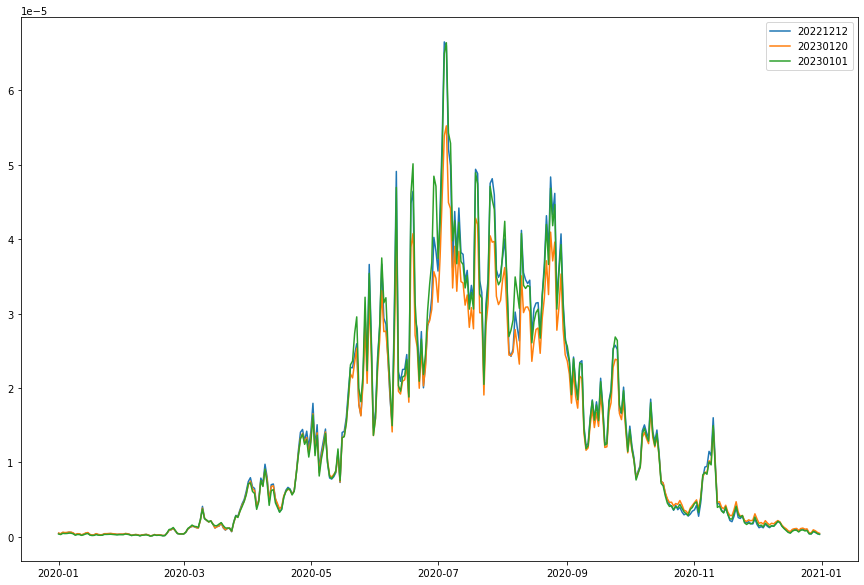

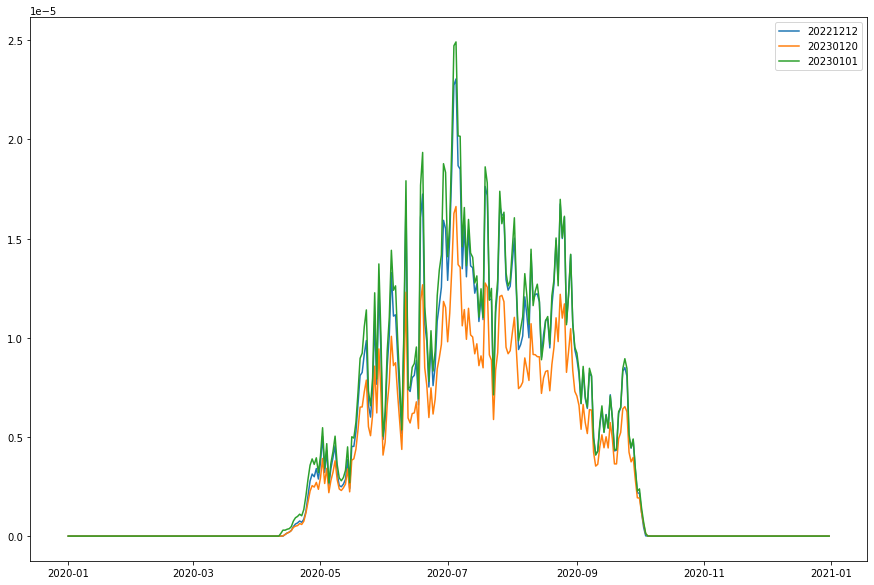

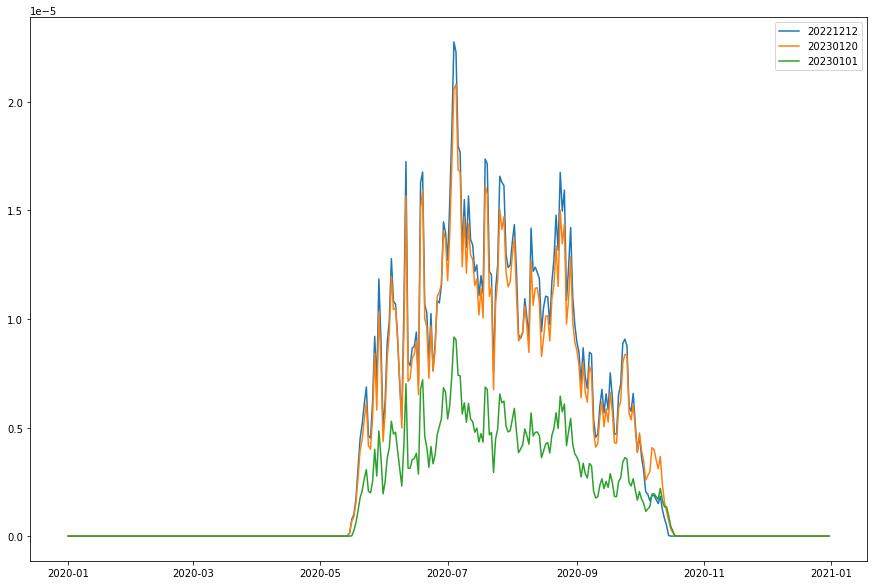

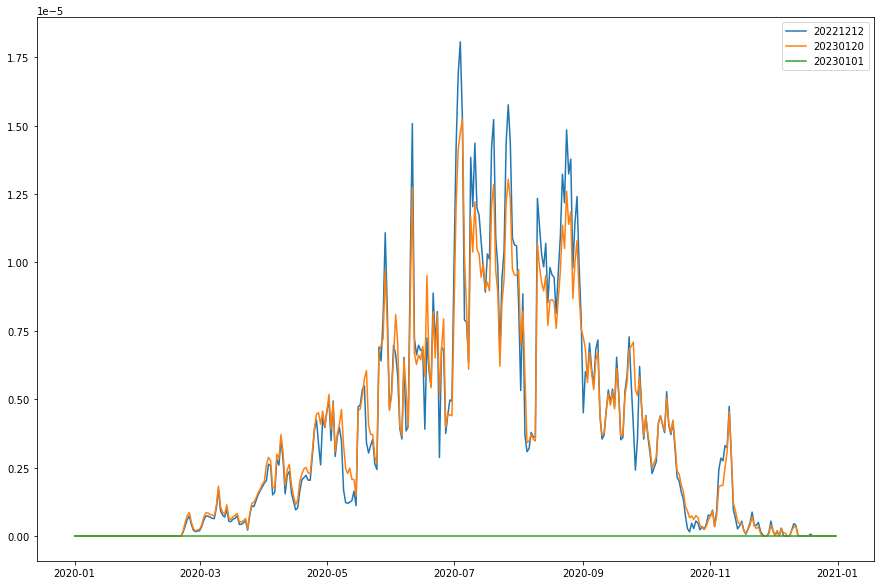

In [3]:
for pft in [2, 3, 11, 12]:
    f1 = os.path.join(path_elm_out, '20221212_plot06_US-SPR_ICB20TRCNPRDCTCBC/run/20221212_plot06_US-SPR_ICB20TRCNPRDCTCBC.clm2.h2.2020-01-01-00000.nc')
    hr = xr.open_dataset(f1, decode_times = False)
    LEAF_MR1 = hr['LEAF_MR'][:, pft] * 0.64 +  hr['LEAF_MR'][:, pft + 17] * 0.36
    hr.close()

    f2 = os.path.join(path_elm_out, '20230120_plot06_US-SPR_ICB20TRCNPRDCTCBC/run/20230120_plot06_US-SPR_ICB20TRCNPRDCTCBC.clm2.h2.2020-01-01-00000.nc')
    hr = xr.open_dataset(f2, decode_times = False)
    LEAF_MR2 = hr['LEAF_MR'][:, pft] * 0.64 +  hr['LEAF_MR'][:, pft + 17] * 0.36
    hr.close()

    f3 = os.path.join(path_elm_out, '20230101_plot06_US-SPR_ICB20TRCNPRDCTCBC/run/20230101_plot06_US-SPR_ICB20TRCNPRDCTCBC.clm2.h2.2020-01-01-00000.nc')
    hr = xr.open_dataset(f3, decode_times = False)
    LEAF_MR3 = hr['LEAF_MR'][:, pft] * 0.64 +  hr['LEAF_MR'][:, pft + 17] * 0.36
    hr.close()

    tvec = pd.date_range(start = '2020-01-01', end = '2020-12-31', freq='D')
    tvec = tvec[(tvec.month != 2) | (tvec.day != 29)]

    fig, ax = plt.subplots(figsize = (15, 10))
    ax.plot(tvec, LEAF_MR1, label = '20221212')
    ax.plot(tvec, LEAF_MR2, label = '20230120')
    ax.plot(tvec, LEAF_MR3, label = '20230101')
    ax.legend()
    fig.savefig(f'./temp/test_LEAF_MR_{pft}.png')

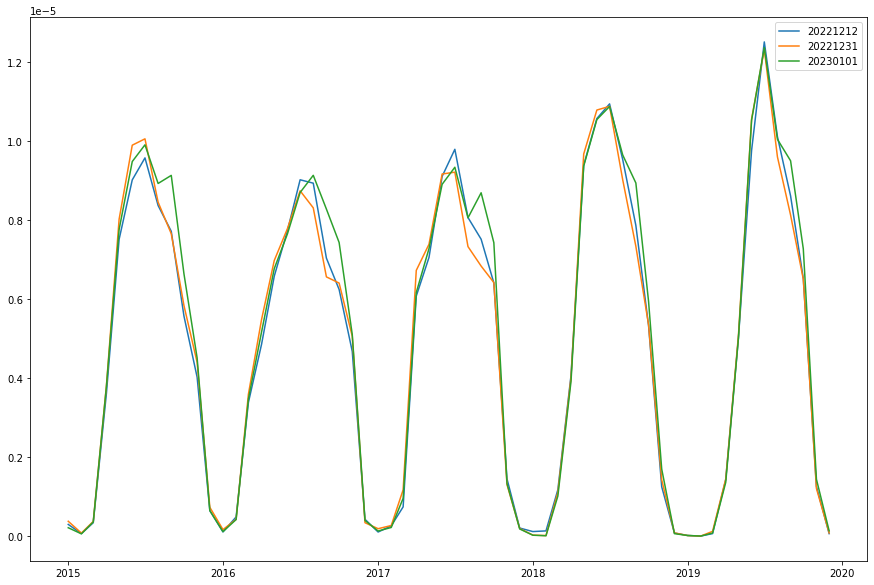

In [14]:
f1 = os.path.join(path_elm_out, '20221212_plot06_US-SPR_ICB20TRCNPRDCTCBC/run/20221212_plot06_US-SPR_ICB20TRCNPRDCTCBC.clm2.h0.2015-02-01-00000.nc')
hr = xr.open_dataset(f1, decode_times = False)
HR1 = hr['HR'][:, 0] * 0.64 +  hr['HR'][:, 1] * 0.36
hr.close()

f2 = os.path.join(path_elm_out, '20221231_plot06_US-SPR_ICB20TRCNPRDCTCBC/run/20221231_plot06_US-SPR_ICB20TRCNPRDCTCBC.clm2.h0.2015-02-01-00000.nc')
hr = xr.open_dataset(f2, decode_times = False)
HR2 = hr['HR'][:, 0] * 0.64 +  hr['HR'][:, 1] * 0.36
hr.close()

f3 = os.path.join(path_elm_out, '20230101_plot06_US-SPR_ICB20TRCNPRDCTCBC/run/20230101_plot06_US-SPR_ICB20TRCNPRDCTCBC.clm2.h0.2015-02-01-00000.nc')
hr = xr.open_dataset(f3, decode_times = False)
HR3 = hr['HR'][:, 0] * 0.64 +  hr['HR'][:, 1] * 0.36
hr.close()

tvec = pd.date_range(start = '2015-01-01', end = '2019-12-31', freq='MS')
tvec = tvec[(tvec.month != 2) | (tvec.day != 29)]

fig, ax = plt.subplots(figsize = (15, 10))
ax.plot(tvec, HR1, label = '20221212')
ax.plot(tvec, HR2, label = '20221231')
ax.plot(tvec, HR3, label = '20230101')
ax.legend()
fig.savefig('./temp/test_HR_grid.png')

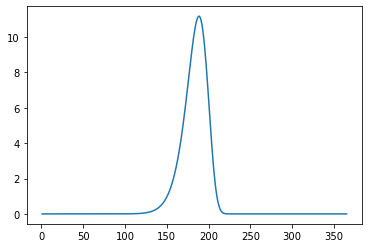

In [28]:
day_of_year = np.arange(1, 366)
maxday_off_evergreen = 180
ndays_off_evergreen = 15
fracday = 0
dayspyr = 365


y = np.exp(-0.5*((day_of_year/maxday_off_evergreen)**ndays_off_evergreen)) * \
    0.5 * ndays_off_evergreen / maxday_off_evergreen * \
        ((day_of_year/maxday_off_evergreen)**(ndays_off_evergreen - fracday)) * dayspyr


plt.plot(day_of_year, y)
plt.show()

100%|██████████| 2500/2500 [05:07<00:00,  8.14it/s]


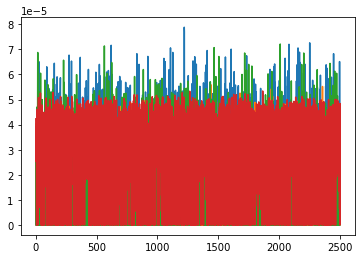

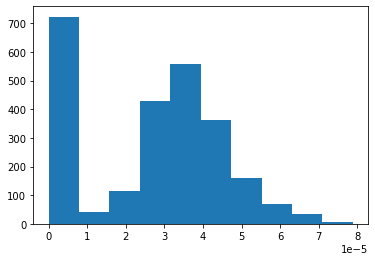

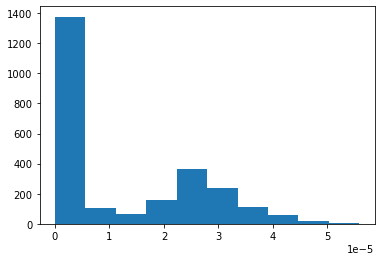

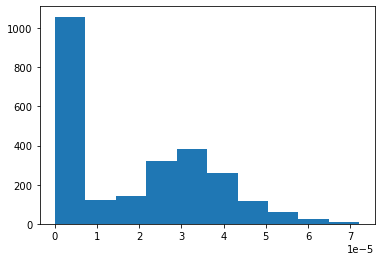

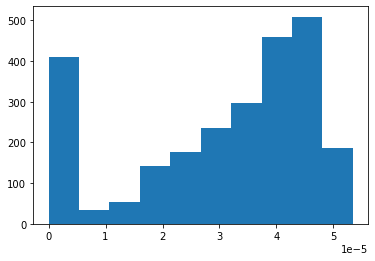

In [13]:
# Check which parameter combinations did not result in AGNPP = 0 for the trees
from tqdm import tqdm
path_root = os.path.join(path_elm_out, 'UQ/UQ_default_US-SPR_ICB20TRCNPRDCTCBC')


gpp = pd.DataFrame(np.nan, index = np.arange(1, 2501), columns = [2, 3, 11, 12])
for i in tqdm(range(1, 2501)):
    file = os.path.join(path_root, f'g{i:05d}', 'T2.25', 'UQ_default_US-SPR_ICB20TRCNPRDCTCBC.clm2.h2.2018-01-01-00000.nc')
    
    hr = xr.open_dataset(file)
    for pft in [2, 3, 11, 12]:
        gpp.loc[i, pft] = hr['GPP'][:, pft].mean() * 0.64 +  hr['GPP'][:, pft + 17].mean() * 0.36
    hr.close()
gpp.to_csv('./temp/GPP_sensitivity.csv')

plt.plot(gpp)
for pft in [2, 3, 11, 12]:
    plt.figure()
    plt.hist(gpp[pft])

100%|██████████| 2500/2500 [04:29<00:00,  9.27it/s]


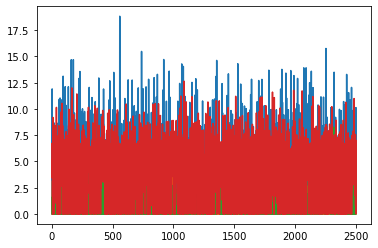

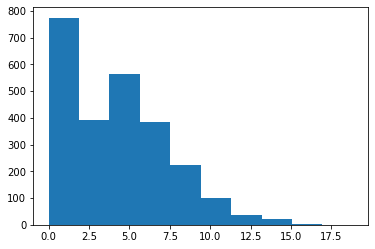

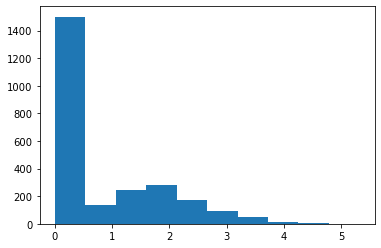

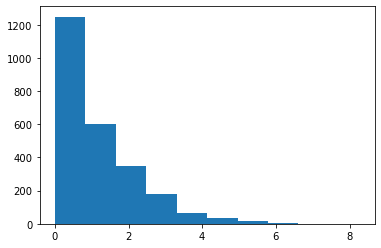

In [5]:
NPP = pd.DataFrame(np.nan, index = np.arange(1, 2501), columns = [2, 3, 11, 12])
for i in tqdm(range(1, 2501)):
    file = os.path.join(path_root, f'g{i:05d}', 'T2.25', 'UQ_default_US-SPR_ICB20TRCNPRDCTCBC.clm2.h2.2018-01-01-00000.nc')

    hr = xr.open_dataset(file)
    for pft in [2, 3, 11, 12]:
        tlai.loc[i, pft] = hr['TLAI'][:, pft].mean() * 0.64 +  hr['TLAI'][:, pft + 17].mean() * 0.36
    hr.close()
tlai.to_csv('./temp/TLAI_sensitivity.csv')

plt.plot(tlai)
for pft in [2, 3, 11, 12]:
    plt.figure()
    plt.hist(tlai[pft])

In [16]:
for var in ['flnr', 'slatop']:
    print(var)
    flnr = pd.DataFrame(np.nan, index = np.arange(1, 2501), columns = [2, 3, 11, 12])
    for i in tqdm(range(1, 2501)):
        file = os.path.join(path_root, f'g{i:05d}', f'clm_params_{i:05d}.nc')

        hr = xr.open_dataset(file)
        for pft in [2, 3, 11, 12]:
            flnr.loc[i, pft] = hr[var][pft]
        hr.close()
    flnr.to_csv(f'./temp/{var}_sensitivity.csv')

flnr


100%|██████████| 2500/2500 [03:17<00:00, 12.66it/s]


slatop


100%|██████████| 2500/2500 [03:18<00:00, 12.62it/s]


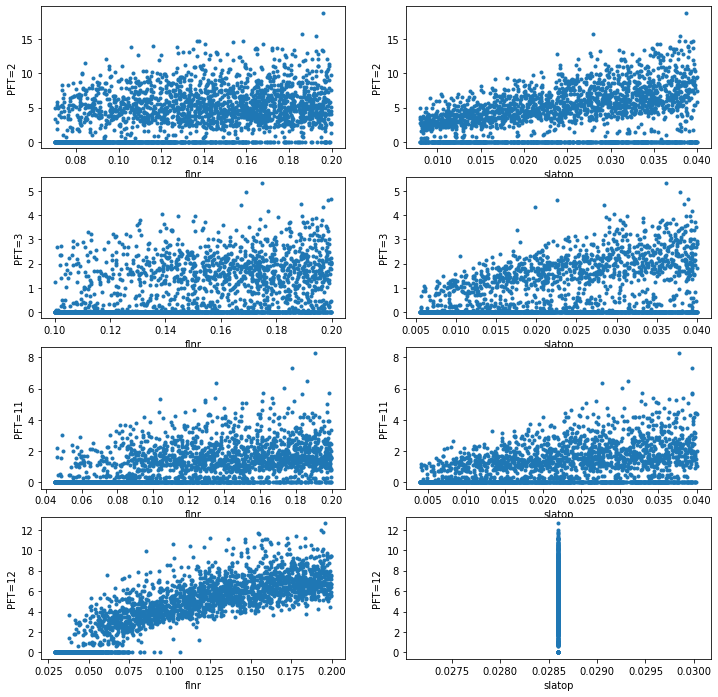

In [17]:
fig, axes = plt.subplots(4, 2, figsize = (12, 12))
for i, pft in enumerate([2, 3, 11, 12]):
    for j, var in enumerate(['flnr', 'slatop']):
        param = pd.read_csv(f'./temp/{var}_sensitivity.csv', index_col = 0)

        ax = axes[i, j]
        ax.plot(param[str(pft)], tlai[pft], '.')
        ax.set_ylabel(f'PFT={pft}')
        ax.set_xlabel(var)

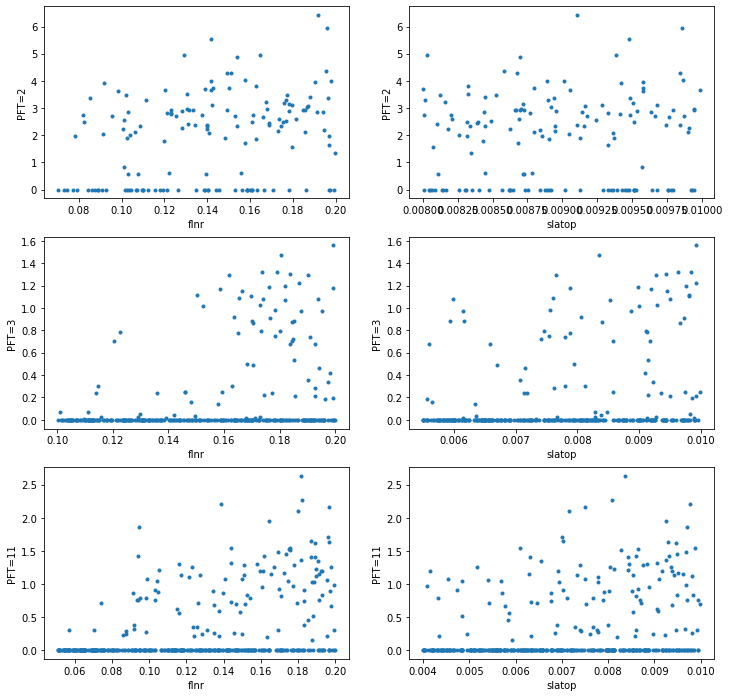

In [18]:
flnr = pd.read_csv(f'./temp/flnr_sensitivity.csv', index_col = 0)
slatop = pd.read_csv(f'./temp/slatop_sensitivity.csv', index_col = 0)

fig, axes = plt.subplots(3, 2, figsize = (12, 12))
for i, pft in enumerate([2, 3, 11]):
    for j, var in enumerate(['flnr', 'slatop']):
        param = pd.read_csv(f'./temp/{var}_sensitivity.csv', index_col = 0)

        ax = axes[i, j]
        ax.plot(param.loc[(flnr[str(pft)] >= 0.05) & (slatop[str(pft)] <= 0.01), str(pft)], tlai.loc[(flnr[str(pft)] >= 0.05) & (slatop[str(pft)] <= 0.01), pft], '.')
        ax.set_ylabel(f'PFT={pft}')
        ax.set_xlabel(var)

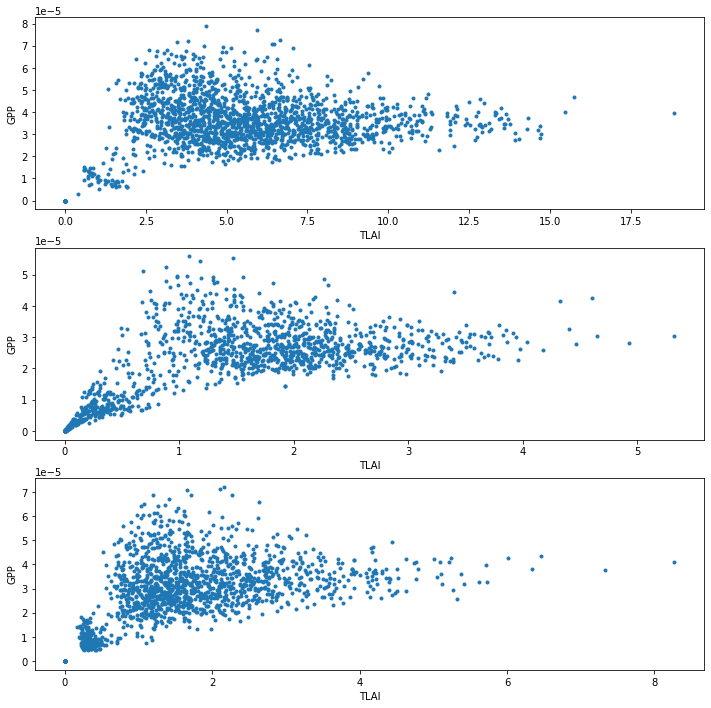

In [20]:
fig, axes = plt.subplots(3, 1, figsize = (12, 12))
for i, pft in enumerate([2, 3, 11]):
    ax = axes[i]
    ax.plot(tlai.loc[flnr[str(pft)] >= 0.05, pft], gpp.loc[flnr[str(pft)] >= 0.05, pft], '.')
    ax.set_ylabel(f'PFT={pft}')
    ax.set_xlabel('TLAI')
    ax.set_ylabel('GPP')

In [21]:
# Focus on the parameter ranges that the LAI of the PFTs are non-zero
non_zero_runs = tlai.index[(tlai[2] > 0) & (tlai[3] > 0) & (tlai[11] > 0)]
print(non_zero_runs)


param_list = ['flnr', 'leaf_long', 'slatop', 'froot_leaf', 'mbbopt', 'q10_mr', 
              'br_mr', 'grperc', 'decomp_depth_efolding', 'qflx_h2osfc_surfrate', 
              'rsub_top_globalmax']

parameters = pd.DataFrame(np.nan, 
    columns = pd.MultiIndex.from_product([param_list, [2, 3, 11, 12]]),
    index = non_zero_runs)

for run in non_zero_runs:
    for p in param_list:
        file = os.path.join(path_root, f'g{run:05d}', f'clm_params_{run:05d}.nc')

        hr = xr.open_dataset(file)

        if p in ['decomp_depth_efolding', 'qflx_h2osfc_surfrate', 'rsub_top_globalmax']:
            parameters.loc[run, p] = float(hr[p])
        else:
            for pft in [2, 3, 11, 12]:
                parameters.loc[run, (p, pft)] = hr[p][pft]
        hr.close()
parameters.to_csv(f'./temp/parameters_sensitivity.csv')

Int64Index([   2,   12,   17,   19,   24,   26,   28,   31,   36,   37,
            ...
            2457, 2467, 2470, 2471, 2474, 2487, 2488, 2489, 2497, 2500],
           dtype='int64', length=643)


In [22]:
parameters_min = parameters.min().unstack()
parameters_max = parameters.max().unstack()

parameters_min.to_csv(f'./temp/parameters_sensitivity_min.csv')
parameters_max.to_csv(f'./temp/parameters_sensitivity_max.csv')